# Retail Sales Prediction - Regression Problem

## 1. Problem Statement
The goal is to predict the **Total Monthly Sales** for each store based on store attributes, calendar patterns, and promotional activity.

## 2. Notebook Flow
*   **Imports and Data Loading**: Load the raw files and create the base monthly dataset.
*   **EDA Reference**: Exploratory analysis is covered separately in `EDA_Promotion_dataset.ipynb`.
*   **Final Feature Engineering**: Add promotion-duration features and save the final modeling dataset.
*   **Model Building**: Reload the saved final dataset, prepare features, train models, and evaluate performance.


# 1. Imports and Setup


In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Display all columns
pd.set_option('display.max_columns', None)


## 2. Loading the Raw Data
Load the source files and parse the date columns needed for aggregation and analysis.


The notebook starts by loading the transaction, store, promotion, and calendar tables that feed the full pipeline.


In [165]:
# Load CSV files
stores = pd.read_csv('raw_data/STORES.csv')
promotions = pd.read_csv('raw_data/PROMOTIONS.csv')
store_promotions = pd.read_csv('raw_data/STORE_PROMOTIONS.csv')

# Load Transactions and Calendar (parsed dates)
transactions = pd.read_csv('raw_data/TRANSACTIONS.csv')
calendar = pd.read_csv('raw_data/CALENDAR.csv')

/var/folders/lq/l9_nf9611z552kdf863clz9w0000gp/T/ipykernel_96560/1709032470.py:7: DtypeWarning: Columns (0: promo_id) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('raw_data/TRANSACTIONS.csv')


In [166]:
transactions['transaction_date']=pd.to_datetime(transactions['transaction_date'])
calendar['date']=pd.to_datetime(calendar['date'])

## 3. Create the Base Monthly Dataset

Build the store-month dataset used for downstream feature engineering and model training.

### Step 1: Create Month and Year Columns


In [167]:
transactions['year'] = transactions['transaction_date'].dt.year
transactions['month'] = transactions['transaction_date'].dt.month


### Step 2: Aggregate Transactions
We will group by `store_id`, `year`, and `month` to calculate total sales and other metrics.


In [168]:
# Aggregate to Store-Month using named aggregation
monthly_sales = transactions.groupby(['store_id', 'year', 'month']).agg(
    total_sales=('net_bill_value', 'sum'),
    total_transactions=('transaction_id', 'count'),
    total_items=('total_items', 'sum')
).reset_index()

### Step 3: Merge Store Metadata
We need to add store information (like City, Size, Format) to our monthly sales data.


In [169]:
# Merge with STORES data
df_merged = pd.merge(monthly_sales, stores, on='store_id', how='left')


### Step 3a: Add Monthly Calendar Features
From `CALENDAR.csv`, create monthly features shared by all stores:
- `days_festive`: days flagged as festive period
- `days_festival_named`: days with a non-empty `festival_name`
- `days_weekend`: weekend days in the month
- `days_in_month`: count of days in the month

In [170]:
# Aggregate to month/year level
calendar['festival_named_flag'] = calendar['festival_name'].fillna('').str.strip().ne('').astype(int)

cal_monthly = calendar.groupby(['year', 'month']).agg(
    days_festive=('is_festive_period', 'sum'),
    days_festival_named=('festival_named_flag', 'sum'),
    days_weekend=('is_weekend', 'sum'),
    days_in_month=('date', 'count')
).reset_index()


In [171]:
# Merge into the store-month dataset (same values for all stores in a month)
df_merged = pd.merge(df_merged, cal_monthly, on=['year', 'month'], how='left')

## 4. Final Feature Engineering

EDA is covered in `EDA_Promotion_dataset.ipynb`, so this notebook continues directly with the final feature set used for modeling.

This step adds promotion-duration features to the base monthly dataset.


In [172]:
from datetime import datetime, timedelta

# Merge promo type into store_promotions for easier filtering
store_promotions_merged = pd.merge(store_promotions, promotions[['promo_id', 'promo_type']], on='promo_id', how='left')

# Convert dates to datetime objects
store_promotions_merged['start_date'] = pd.to_datetime(store_promotions_merged['start_date'])
store_promotions_merged['end_date'] = pd.to_datetime(store_promotions_merged['end_date'])

def calculate_active_days(store_id, year, month, promo_type, promo_df):
    
    # 1. Define the start and end of the month
    month_start = datetime(year, month, 1)
    if month == 12:
        month_end = datetime(year, 12, 31)
    else:
        month_end = datetime(year, month + 1, 1) - timedelta(days=1)
        
    # 2. Filter for specific store and promo type
    relevant_promos = promo_df[
        (promo_df['store_id'] == store_id) & 
        (promo_df['promo_type'] == promo_type)
    ]
    
    total_days = 0
    
    # 3. Calculate overlap
    for _, row in relevant_promos.iterrows():
        # Find overlap start and end
        overlap_start = max(month_start, row['start_date'])
        overlap_end = min(month_end, row['end_date'])
        
        # Check if there is an actual overlap
        if overlap_start <= overlap_end:
            days = (overlap_end - overlap_start).days + 1
            total_days += days
            
    return total_days

def calculate_active_days_for_row(row, promo_type, promo_df):
    return calculate_active_days(row['store_id'], row['year'], row['month'], promo_type, promo_df)


Apply the helper function to create one active-days feature for each promotion type.
*Note: This may take a minute to run.*


In [173]:
# Get unique promotion types
promo_types = promotions['promo_type'].unique()

for p_type in promo_types:
    col_name = f'days_{p_type}'
    print(f"Calculating {col_name}...")
    
    # Use apply with a named helper function
    df_merged[col_name] = df_merged.apply(
        calculate_active_days_for_row,
        axis=1,
        args=(p_type, store_promotions_merged)
    )

print("Feature Engineering Complete.")


Calculating days_BOGO...
Calculating days_Flat_50...
Calculating days_Kids_Special...
Calculating days_Summer_Sale...
Calculating days_Festive_Bonanza...
Calculating days_Clearance...
Feature Engineering Complete.


Save the engineered dataset so the modeling section can reload it directly.


In [174]:
final_data_path = 'final_data.csv'
df_merged.to_csv(final_data_path, index=False)
print(f"Saved engineered dataset to {final_data_path} with shape {df_merged.shape}")


Saved engineered dataset to final_data.csv with shape (3000, 26)


Reload the saved dataset for model building so the rest of the notebook always uses the latest engineered data.


In [175]:
df_merged = pd.read_csv('final_data.csv', parse_dates=['launch_date'])
print(f"Loaded final_data.csv with shape {df_merged.shape}")


Loaded final_data.csv with shape (3000, 26)


## 5. Pre-processing for Machine Learning

Use the saved engineered dataset for the modeling steps below. This avoids relying on the old monthly dataset file.

### Step 1: Handling Categorical Variables
We use **OneHotEncoder** to convert text columns into model-ready features.


In [176]:
# Feature Selection
target = 'total_sales'
drop_cols = ['Date']

# `days_festival_named` is a monthly count, so keep it numeric.
categorical_cols = ['store_format', 'location_type', 'city', 'state', 'zone']
numerical_cols = [
    c for c in df_merged.columns
    if c not in categorical_cols + [target, 'store_id', 'launch_date', *drop_cols]
]
model_cols = numerical_cols + categorical_cols

print(f"Categorical: {categorical_cols}")
print(f"Numerical: {numerical_cols}")
print("Feature count:", len(model_cols))


Categorical: ['store_format', 'location_type', 'city', 'state', 'zone']
Numerical: ['year', 'month', 'total_transactions', 'total_items', 'store_size_sqft', 'competition_density', 'avg_monthly_footfall', 'avg_monthly_sales', 'days_festive', 'days_festival_named', 'days_weekend', 'days_in_month', 'days_BOGO', 'days_Flat_50', 'days_Kids_Special', 'days_Summer_Sale', 'days_Festive_Bonanza', 'days_Clearance']
Feature count: 23


### Step 2: Train-Test Split
Since we have time-series data, random splitting is bad. We will use a **time-based split**.
*   **Train**: 2024 and earlier
*   **Test**: 2025


In [177]:
# Create time-based train/test splits
train_mask = (df_merged['year'] <= 2024)
test_mask = (df_merged['year'] == 2025)

train_df = df_merged.loc[train_mask].sort_values(['year', 'month', 'store_id']).reset_index(drop=True)
test_df = df_merged.loc[test_mask].sort_values(['year', 'month', 'store_id']).reset_index(drop=True)

X_train = train_df[model_cols]
y_train = train_df[target]
X_test = test_df[model_cols]
y_test = test_df[target]

# Use expanding yearly folds so validation matches the final time-based test setup.
validation_years = [2022, 2023, 2024]
time_splits = []
for val_year in validation_years:
    fold_train_idx = train_df.index[train_df['year'] < val_year].to_numpy()
    fold_val_idx = train_df.index[train_df['year'] == val_year].to_numpy()
    time_splits.append((fold_train_idx, fold_val_idx))

print(f"Train Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")
for fold_number, (_, val_idx) in enumerate(time_splits, start=1):
    print(f"Fold {fold_number}: validate on {validation_years[fold_number - 1]} ({len(val_idx)} rows)")


Train Set: (2400, 23)
Test Set: (600, 23)
Fold 1: validate on 2022 (600 rows)
Fold 2: validate on 2023 (600 rows)
Fold 3: validate on 2024 (600 rows)


### Step 3: Preprocessing Pipeline
Build a fold-safe preprocessing pipeline so each validation fold learns its own transformations.


In [178]:
# Preprocessing Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

preprocessor = make_column_transformer(
    (StandardScaler(), numerical_cols),
    (OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
    verbose_feature_names_out=False
)

print("Preprocessor ready. It will be fitted inside each model pipeline and validation fold.")

Preprocessor ready. It will be fitted inside each model pipeline and validation fold.


## 6. Machine Learning Models

### Model 1: Linear Regression (Baseline)


We start with a simple baseline and then compare it with a tree-based ensemble model.


In [179]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = make_pipeline(
    preprocessor,
    LinearRegression()
)
lr_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [180]:
# Predict
y_pred_lr = lr_model.predict(X_test)


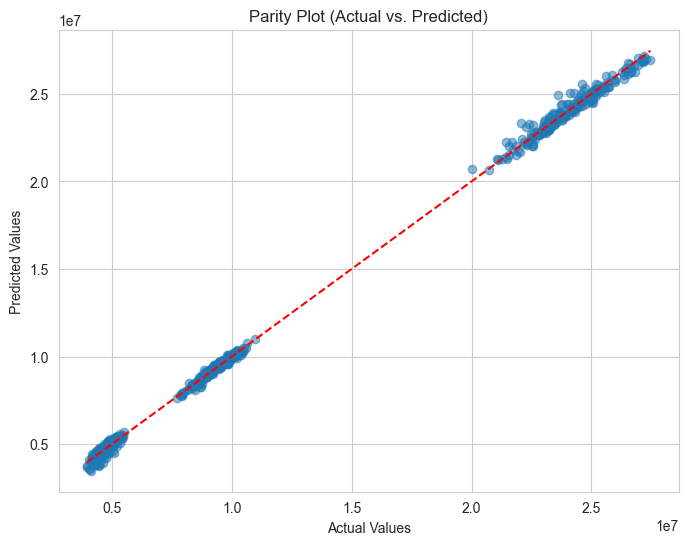

In [181]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Parity Plot (Actual vs. Predicted)')
plt.grid(True)
plt.show()


In [182]:
# Evaluate
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression RMSE: {round(rmse_lr, 2)}")

Linear Regression RMSE: 236710.35


### Model 2: Random Forest Regressor


In [183]:
from sklearn.ensemble import RandomForestRegressor

rf_model = make_pipeline(
    preprocessor,
    RandomForestRegressor(n_estimators=100, random_state=42)
)
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

In [184]:
# Predict
y_pred_rf = rf_model.predict(X_test)


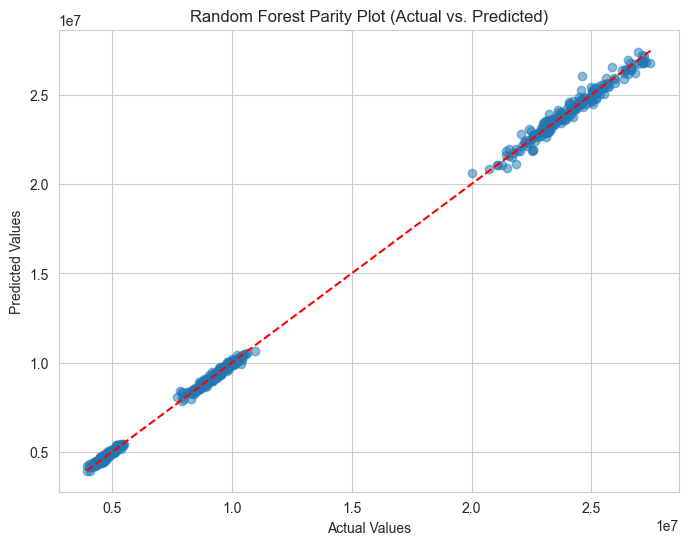

In [185]:
# Parity plot for Random Forest predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Parity Plot (Actual vs. Predicted)')
plt.grid(True)
plt.show()


In [186]:
# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest RMSE: {round(rmse_rf, 2)}")

Random Forest RMSE: 199385.7


### 6.1 Cross-Validation
To ensure the model performance is stable and not a split-specific result, we evaluate it with cross-validation.


In [187]:
from sklearn.model_selection import cross_val_score

# Evaluate the untuned forest with the same time-based validation used for tuning.
scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring='neg_mean_squared_error',
    cv=time_splits,
    n_jobs=1
)

rmse_scores = np.sqrt(-scores)
print(f"Time-based CV RMSE Scores: {np.round(rmse_scores, 2)}")
print(f"Average RMSE: {round(rmse_scores.mean(), 2)}")


Time-based CV RMSE Scores: [295998.44 221297.81 193835.08]
Average RMSE: 237043.78


### 6.2 Hyperparameter Tuning (GridSearchCV)
Tune the Random Forest settings to improve generalization on the holdout period.


In [188]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid.
# Include the default configuration so tuning can keep it if it is best.
param_grid = {
    'randomforestregressor__n_estimators': [100, 200],
    'randomforestregressor__max_depth': [None, 20, 30],
    'randomforestregressor__min_samples_split': [2, 5, 10],
    'randomforestregressor__min_samples_leaf': [1, 2]
}


In [194]:
# 2. Initialize the Grid Search
grid_search = GridSearchCV(
    estimator=make_pipeline(
        preprocessor,
        RandomForestRegressor(random_state=42)
    ),
    param_grid=param_grid,
    cv=time_splits,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    refit=True
)

In [195]:
# 3. Fit
print("Starting Grid Search... this may take a moment.")
grid_search.fit(X_train, y_train)

Starting Grid Search... this may take a moment.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestregressor__max_depth': [None, 20, ...], 'randomforestregressor__min_samples_leaf': [1, 2], 'randomforestregressor__min_samples_split': [2, 5, ...], 'randomforestregressor__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0, ... 598, 5

In [191]:
# 4. Best Results
print(f"Best Parameters: {grid_search.best_params_}")
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Best CV RMSE: {round(best_rmse, 2)}")

Best Parameters: {'randomforestregressor__max_depth': 20, 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__min_samples_split': 5, 'randomforestregressor__n_estimators': 200}
Best CV RMSE: 238940.43


In [192]:

# 5. Predict with Best Model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"Final Test RMSE with Tuned Model: {round(final_rmse, 2)}")

Final Test RMSE with Tuned Model: 197649.84


## 7. Conclusion & Feature Importance
Review the key drivers identified by the tuned Random Forest model.


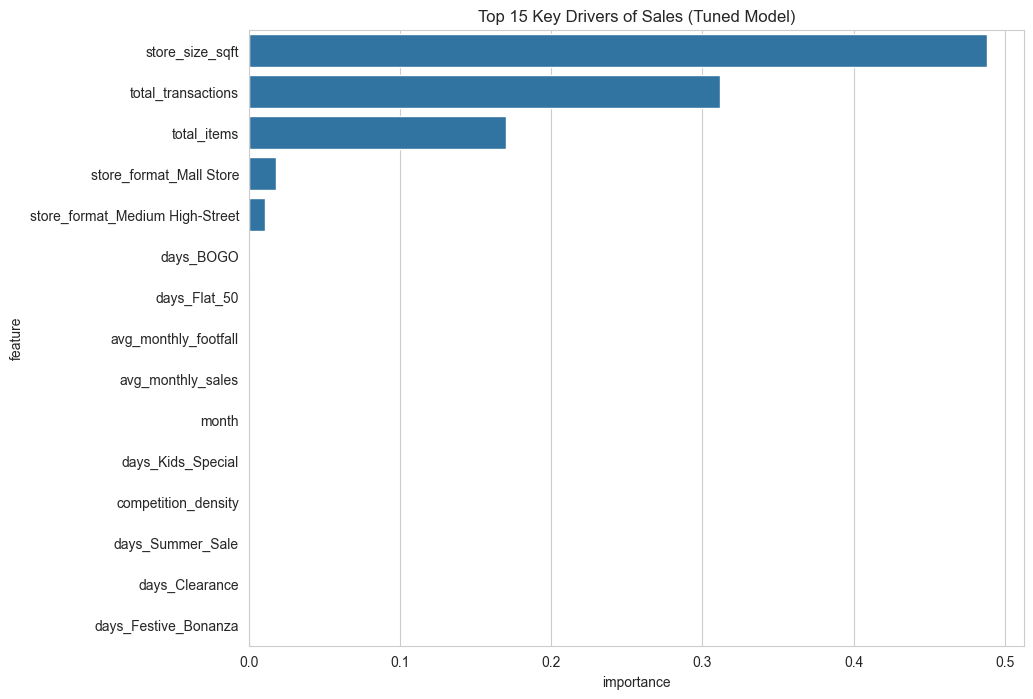

In [193]:
# Feature Importance
feature_names = best_rf.named_steps['columntransformer'].get_feature_names_out()
feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.named_steps['randomforestregressor'].feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feature_importances.head(15), x='importance', y='feature', ax=ax)
ax.set_title('Top 15 Key Drivers of Sales (Tuned Model)')
plt.show()
